# FX Value (PPP) — a quantitative teardown 🔬
### The real-rate value sort · Newey-West HAC inference · a 10,000-draw random-sign placebo · a trailing-window robustness sweep · an honest cost+borrow timer · a 20-seed synthetic control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Survivorship: Named](https://img.shields.io/badge/Survivorship-Named-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — **undervalued real exchange rates predict currency appreciation** — is the FX **value** factor, the opposite tilt to carry (study 364) and a real time series of the PPP gap, not the Big-Mac snapshot (study 215). The job: measure it point-in-time on the G10, run the autocorrelation-robust inference, and ask whether it clears the bar and survives costs.

> ⚠️ **Data note.** G10 FX vs USD (yfinance, month-end, USD-per-foreign) + national CPI (IMF IFS monthly; Eurostat HICP for EUR; IMF IFS **quarterly** ffill for AUD & NZD). Real rate `log q = log S + log CPI_i − log CPI_US`, CPI lagged 1 month (publication lag). 2005-01 → 2025-06. Fingerprints `fx=0f1dcad0ff54`, `cpi=4553d2b68c91`. Numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from fx_value import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    FX = data.load_fx()
    CPI = data.load_cpi()
    LOGQ = data.real_rate_panel(FX, CPI)
    SIG = st.value_signal(LOGQ, window=data.TRAIL_WINDOW, min_periods=data.MIN_TRAIL)
    RETS = st.spot_returns(FX)
    PORT = st.portfolio_returns(SIG, RETS)
else:
    FX = CPI = LOGQ = SIG = RETS = PORT = None
print("real cache present:", HAVE_REAL, "| value LS months:",
      (0 if PORT is None else len(PORT)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2005-01', 'end': '2025-06', 'as_of': '2025-06-30', 'n_months': 246, 'mean_bps': 8.52, 'ann_pct': 1.02, 'vol_ann_pct': 3.39, 'sharpe': 0.3, 't_one': 1.37, 't_nw': 1.58, 'hit': 129, 'hit_pct': 52.4, 'wilson': (46.2, 58.6), 'placebo_obs': 0.302, 'placebo_mean': -0.001, 'placebo_sd': 0.223, 'placebo_p': 0.0905, 'placebo_draws': 10000, 'win': {36: (0.2, 0.92), 48: (0.25, 1.29), 60: (0.3, 1.58), 84: (0.3, 1.64)}, 'era_early_sharpe': 0.06, 'era_early_t': 0.24, 'era_early_n': 120, 'era_late_sharpe': 0.66, 'era_late_t': 2.15, 'era_late_n': 126, 'timer': {5: (1.02, 0.34, 0.1, 0.53), 10: (1.02, 0.16, 0.05, 0.25), 20: (1.02, -0.2, -0.06, -0.32)}, 'turnover': 0.3, 'worst_month': -3.73, 'borrow_bps': 100, 'syn_null_mean': 0.34, 'syn_null_sd': 0.87, 'syn_null_fire': 1, 'syn_planted_t': 12.44, 'syn_planted_sharpe': 2.24, 'syn_planted_ann': 7.34, 'cheap': 'JPY', 'cheap_sig': 0.12, 'rich': 'GBP', 'rich_sig': -0.089, 'fp_fx': '0f1dcad0ff54', 'fp_cpi': '4553d2b68c91'}


real cache present: True | value LS months: 246


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | value LS **+1.02%/yr**, Sharpe 0.30, one-sample t = 1.37, **NW t = 1.58** (< 2), placebo p = 0.09 |
| **Tradability** | `MIRAGE` | net of 5 bps + 100 bps borrow: Sharpe 0.10 (t = 0.53); **negative** by 20 bps (-0.20%/yr) |
| **Survivorship** | `NAMED` | fixed current-membership G10; the premium is documented to live in the *excluded* EM currencies |

> 💡 In plain words: the PPP-value tilt has the right sign and a deep literature behind it, but on the G10-only tape the robust *t* is 1.58 — below the bar — and the gross premium is too thin to survive costs and borrow. Weak, and a mirage to trade.

## 1 · The claim, steelmanned

Let $S_i$ be the USD price of currency $i$ (USD-per-foreign), $P_i$ its CPI. The **log real exchange rate** is

$$q_{i,t} = \log S_{i,t} + \log P_{i,t} - \log P_{US,t}.$$

A *high* $q$ means the currency is **rich** (overvalued) vs PPP; a *low* $q$ means **cheap**. The value signal is the deviation from a trailing average,

$$v_{i,t} = \overline{q}_{i,t}^{\,(60m)} - q_{i,t},$$

positive when the real rate is below its own 5-year mean. The claims:

- **H₁ (reversion).** $E[\Delta S_{i,t+1} \mid v_{i,t}] > 0$ increasing in $v$ — cheap currencies appreciate.
- **H₂ (cross-section).** A dollar-neutral long-cheap/short-rich book earns a positive premium (NW $t \ge 2$).
- **H₃ (capture).** It survives turnover cost and short borrow.

We find **H₁/H₂ directionally supported but statistically WEAK** (NW t = 1.58, placebo p = 0.09) and **H₃ rejected** (net Sharpe 0.10 at 5 bps, negative by 20 bps).

## 2 · So what? — inference design

The monthly long-short return is mildly autocorrelated (overlapping trailing-mean signals move slowly), so the **planned primary is a Newey-West (6-lag) HAC *t*** on the LS mean, with the plain one-sample *t* alongside. The hit rate carries a **Wilson** interval; the placebo **randomly flips each month's cross-sectional signs** (10,000 books, 20 seeds × 500) holding the gross book and return tape fixed; a **trailing-window sweep** (36/48/60/84 mo) checks the result isn't a single lucky memory length. A 2015 sub-period split is examined but flagged **snooped** and kept out of the stamp.

## 3 · How we'd know — the protocol

- **Panel.** 9 G10 currencies vs USD, 2005-01 → 2025-06, 246 monthly LS observations after the trailing window warms up.
- **Signal.** `trailing-mean(log q, 60m, min 36m) − log q`, CPI lagged 1 month; dollar-neutral rank weights (sum w = 0, gross = 1), long cheap / short rich.
- **Execution.** One shift: weights set at close of month *t* earn month *t+1* spot return.
- **Headline.** One-sample + NW(6) *t*, Sharpe, Wilson hit rate, 10,000-draw sign placebo.
- **Robustness.** Trailing-window sweep; a (snooped) pre/post-2015 split.
- **Timer.** Turnover × one-way cost (both legs) + 100 bps/yr short borrow; sweep 5/10/20 bps.
- **Control.** Synthetic real-rate panel with a tunable planted reversion; the null (strength 0) must not systematically fire across 20 seeds.

## 4 · The teardown

### 4a · The headline value sort

The dollar-neutral long-cheap/short-rich book, its cumulative path, and the robust inference.

months 246 (2005-01-31 -> 2025-06-30)
mean +8.52 bps/mo | ann +1.02% | vol 3.39% | Sharpe 0.30
one-sample t = +1.37 | Newey-West(6) t = +1.58
hit 129/246 = 52.4% Wilson [46.2%, 58.6%]


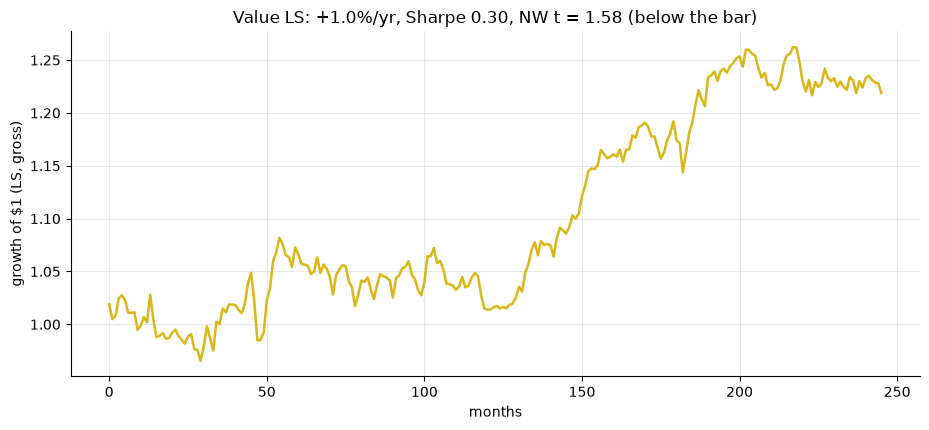

In [2]:
if HAVE_REAL:
    h = st.headline_stats(PORT)
    print(f"months {h['n_months']} ({h['start']} -> {h['end']})")
    print(f"mean {h['mean_bps']:+.2f} bps/mo | ann {h['ann_pct']:+.2f}% | "
          f"vol {h['vol_ann_pct']:.2f}% | Sharpe {h['sharpe']:.2f}")
    print(f"one-sample t = {h['t_one_sample']:+.2f} | Newey-West(6) t = {h['t_nw']:+.2f}")
    print(f"hit {h['hit']}/{h['n_months']} = {h['hit_rate']*100:.1f}% "
          f"Wilson [{h['hit_lo']*100:.1f}%, {h['hit_hi']*100:.1f}%]")
    curve = (1 + PORT).cumprod()
else:
    rng = np.random.default_rng(797)
    curve = (1 + pd.Series(rng.normal(R['mean_bps']/1e4, R['vol_ann_pct']/100/np.sqrt(12), R['n_months']))).cumprod()
fig, ax = plt.subplots(figsize=(9.4, 4.4))
ax.plot(curve.values, color=AMBER, lw=1.8)
ax.set_ylabel('growth of $1 (LS, gross)'); ax.set_xlabel('months')
ax.set_title(f"Value LS: +{R['ann_pct']:.1f}%/yr, Sharpe {R['sharpe']:.2f}, "
             f"NW t = {R['t_nw']:.2f} (below the bar)")
plt.tight_layout(); plt.show()

> 💡 In plain words: **+1.02%/yr** at Sharpe **0.30**, hit rate 52.4% (Wilson [46.2%, 58.6%] — brackets 50%). The robust **NW t = 1.58** and one-sample **t = 1.37** both sit under 2. Right sign, insufficient evidence: **H₂ is WEAK, not REAL.**

### 4b · The placebo — is the sign structure lucky?

Randomly flip each month's cross-sectional signs (gross book & tape fixed), 10,000 books. In the notebook we run a light draw and quote the canonical p from `results.md`.

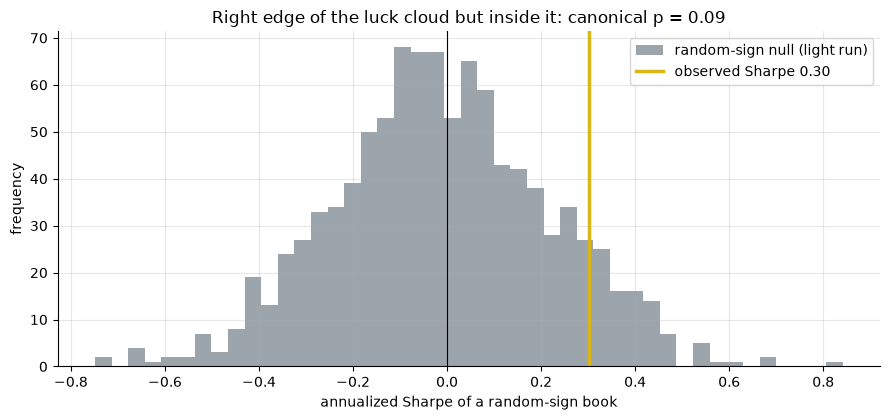

canonical placebo (results.md): mean -0.001, sd 0.223, p = 0.0905 over 10,000 draws


In [3]:
if HAVE_REAL:
    pl = st.placebo_pvalue(SIG, RETS, n_draws_per_seed=200, n_seeds=5)
    obs, draws = pl['obs_sharpe'], pl['draws']
else:
    obs = R['placebo_obs']
    rng = np.random.default_rng(797)
    draws = rng.normal(R['placebo_mean'], R['placebo_sd'], 2000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=45, color=GREY, alpha=.85, label='random-sign null (light run)')
ax.axvline(obs, c=AMBER, lw=2.5, label=f'observed Sharpe {obs:.2f}')
ax.axvline(0, c='k', lw=.8)
ax.set_xlabel('annualized Sharpe of a random-sign book'); ax.set_ylabel('frequency')
ax.set_title(f"Right edge of the luck cloud but inside it: canonical p = {R['placebo_p']:.2f}")
ax.legend(); plt.tight_layout(); plt.show()
print(f"canonical placebo (results.md): mean {R['placebo_mean']:.3f}, "
      f"sd {R['placebo_sd']:.3f}, p = {R['placebo_p']:.4f} over {R['placebo_draws']:,} draws")

> 💡 In plain words: **p = 0.09** — about 1 random-sign book in 11 matches the real sort. Consistent with a genuine but modest tilt; nowhere near the 5% the desk needs to call it decisive. Agrees with the sub-2 *t*.

### 4c · Robustness — trailing-window sweep & a (snooped) era split

Does the memory length matter, and is the effect stable in time?

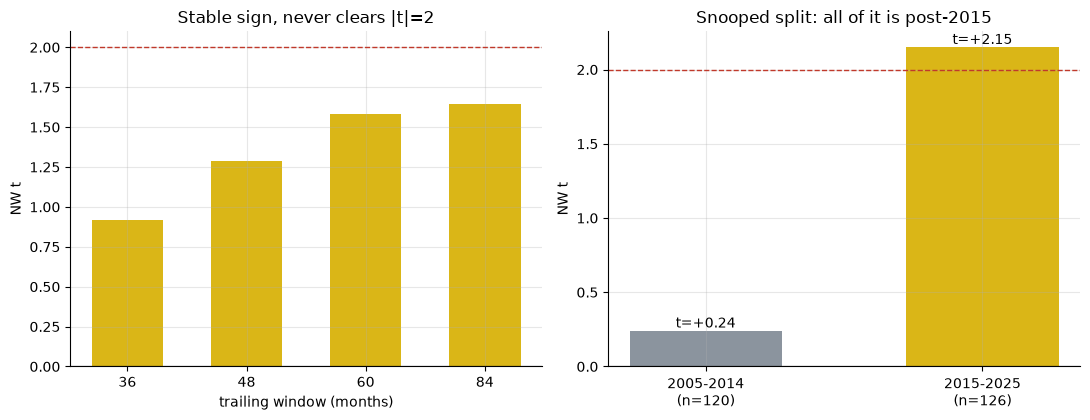

window NW t: {36: 0.92, 48: 1.29, 60: 1.58, 84: 1.64}


In [4]:
wins = sorted(R['win'])
if HAVE_REAL:
    ts = []
    for w_ in wins:
        s2 = st.value_signal(LOGQ, window=w_, min_periods=data.MIN_TRAIL)
        ts.append(st.headline_stats(st.portfolio_returns(s2, RETS))['t_nw'])
else:
    ts = [R['win'][w_][1] for w_ in wins]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.3))
a1.bar([str(w_) for w_ in wins], ts, color=AMBER, width=.6)
a1.axhline(2, ls='--', c=RED, lw=1); a1.axhline(0, c='k', lw=.8)
a1.set_xlabel('trailing window (months)'); a1.set_ylabel('NW t')
a1.set_title('Stable sign, never clears |t|=2')
a2.bar(['2005-2014\n(n={})'.format(R['era_early_n']),'2015-2025\n(n={})'.format(R['era_late_n'])],
       [R['era_early_t'], R['era_late_t']], color=[GREY, AMBER], width=.55)
a2.axhline(2, ls='--', c=RED, lw=1); a2.axhline(0, c='k', lw=.8)
a2.set_ylabel('NW t'); a2.set_title('Snooped split: all of it is post-2015')
for i,v in enumerate([R['era_early_t'], R['era_late_t']]): a2.annotate(f't={v:+.2f}',(i,v),ha='center',va='bottom')
plt.tight_layout(); plt.show()
print('window NW t:', {w_: round(t,2) for w_,t in zip(wins, ts)})

> 💡 In plain words: every window (36→84 mo) gives the same modest positive sign, none clearing |t| = 2 — so the headline isn't a lucky memory length. The 2015 split is eye-catching (pre-2015 t = 0.24, post-2015 t = 2.15) but it is **not pre-registered**: a hypothesis for follow-up (does G10 value only pay in high-rate-vol regimes?), never a certification. The full-sample number governs the stamp.

### 4d · The timer — costs and short borrow

Turnover × one-way cost on both legs, plus a 100 bps/yr borrow on the short book.

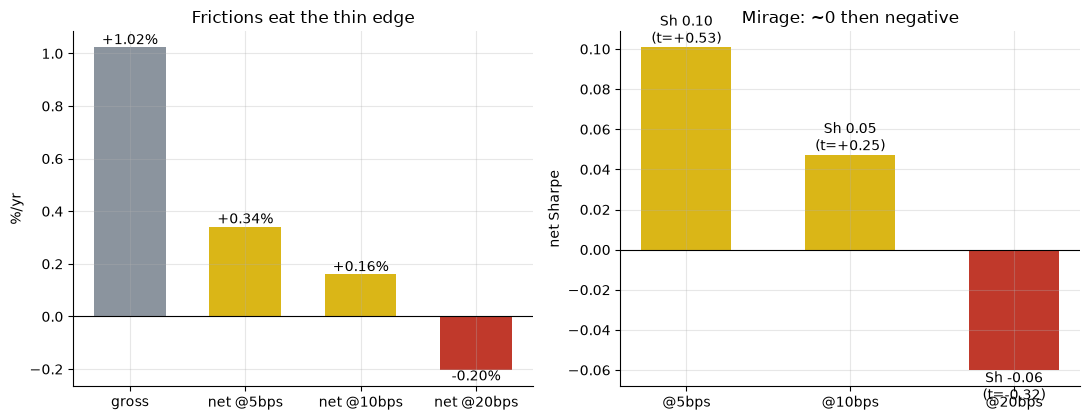

net %/yr: {5: 0.34, 10: 0.16, 20: -0.2}


In [5]:
levels = sorted(R['timer'])
if HAVE_REAL:
    gross, nets, sharpes, tts = [], [], [], []
    for c in levels:
        t = st.timer_stats(SIG, RETS, cost_bps=c)
        gross.append(t['gross_ann_pct']); nets.append(t['net_ann_pct'])
        sharpes.append(t['net_sharpe']); tts.append(t['net_t_nw'])
else:
    gross = [R['timer'][c][0] for c in levels]; nets = [R['timer'][c][1] for c in levels]
    sharpes = [R['timer'][c][2] for c in levels]; tts = [R['timer'][c][3] for c in levels]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.3))
a1.bar(['gross']+[f'net @{c}bps' for c in levels], [gross[0]]+nets,
       color=[GREY]+[AMBER if v>0 else RED for v in nets], width=.62)
for i,v in enumerate([gross[0]]+nets): a1.annotate(f'{v:+.2f}%',(i,v),ha='center',va='bottom' if v>=0 else 'top')
a1.axhline(0, c='k', lw=.8); a1.set_ylabel('%/yr'); a1.set_title('Frictions eat the thin edge')
a2.bar([f'@{c}bps' for c in levels], sharpes, color=[AMBER if v>0 else RED for v in sharpes], width=.55)
for i,(v,t_) in enumerate(zip(sharpes, tts)): a2.annotate(f'Sh {v:.2f}\n(t={t_:+.2f})',(i,v),ha='center',va='bottom' if v>=0 else 'top')
a2.axhline(0, c='k', lw=.8); a2.set_ylabel('net Sharpe'); a2.set_title('Mirage: ~0 then negative')
plt.tight_layout(); plt.show()
print('net %/yr:', {c: R['timer'][c][1] for c in levels})

> 💡 In plain words: gross **+1.02%/yr** → net **+0.34%** at 5 bps (Sharpe 0.10), **+0.16%** at 10 bps, and **-0.20%** — negative — at 20 bps. Turnover ≈ 0.30/mo and the 100 bps short borrow together outweigh the premium. Worst month -3.7%. **Tradability = MIRAGE.**

### 4e · Faithful-engine & power control — we know the truth here

Synthetic panel of log real rates with a TUNABLE planted mean reversion. The null (strength = 0, driftless walks) is checked over **20 seeds**.

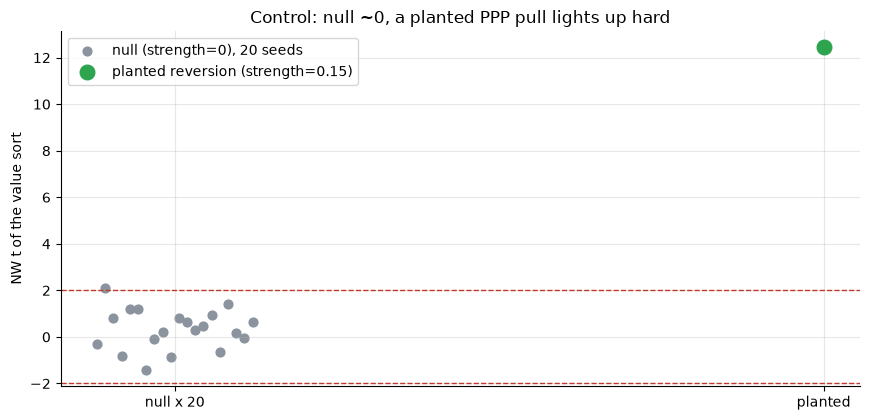

null: mean t = +0.34 (sd 0.87), |t|>=2 in 1/20  |  planted t = +12.44


In [6]:
null_ts = []
for s_ in range(20):
    w = data.synthetic_world(value_strength=0.0, seed=797 + s_)
    null_ts.append(st.synthetic_detect(w)['t_nw'])
null_ts = np.asarray(null_ts)
planted = st.synthetic_detect(data.synthetic_world(value_strength=0.15, seed=797))['t_nw']
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.linspace(-.12,.12,20), null_ts, color=GREY, s=40, label='null (strength=0), 20 seeds')
ax.scatter([1], [planted], color=GREEN, s=110, zorder=5, label='planted reversion (strength=0.15)')
ax.axhline(2, ls='--', c=RED, lw=1); ax.axhline(-2, ls='--', c=RED, lw=1)
ax.set_xticks([0,1]); ax.set_xticklabels(['null x 20','planted'])
ax.set_ylabel('NW t of the value sort')
ax.set_title('Control: null ~0, a planted PPP pull lights up hard')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: mean t = {null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(abs(null_ts)>=2).sum()}/20  |  planted t = {planted:+.2f}')

> 💡 In plain words: across 20 null worlds the detector averages t = +0.34 (sd 0.87), firing at |t| ≥ 2 in only 1/20 (≈ the nominal 5%); a planted reversion reads t = 12.4 (Sharpe 2.24). The machinery recovers the effect it is designed to harvest — so the sub-2 real-tape *t* is a property of the **G10 tape**, not a broken pipeline. *(Machinery/power check only — never cited for the real-tape stamp.)*

## 5 · The verdict

- **Signal `WEAK`** — value LS **+1.02%/yr**, Sharpe 0.30, one-sample t = 1.37, NW t = 1.58 (**< 2**), placebo p = 0.09, hit 52.4% (Wilson brackets 50%). Right sign, deep literature, but this G10 tape cannot certify it. Literature says real; the tape reads WEAK.
- **Tradability `MIRAGE`** — net Sharpe 0.10 at 5 bps, 0.05 at 10 bps, and **negative** (-0.20%/yr) at 20 bps once turnover (~0.30/mo) and 100 bps short borrow are charged. The gross cushion is thinner than its own frictions.
- **Survivorship `NAMED`** — a fixed, current-membership developed-market basket; the documented FX-value premium is disproportionately an **emerging-market** phenomenon this study excludes, so the weakness is partly a basket choice, stated openly.

## 6 · Going further

- **Where the premium actually lives:** Menkhoff et al. (2017) locate most of FX value in EM currencies; extending the basket (with its fatter crash risk and thinner data) is the natural next study.
- **Value × carry:** the two styles are negatively correlated; a combined book ([364-fx-carry-trade](../../364-fx-carry-trade/) is the carry leg) can be steadier than either alone even when each is thin.
- **Signal variants:** the 5-year *change* in the real rate (Asness et al. 2013) vs the *level*-deviation used here; a half-life-matched horizon; or including the interest differential to trade *total* rather than spot returns (which starts to blend value with carry).
- **Dedup map:** [215-big-mac-ppp](../../215-big-mac-ppp/) (single folklore snapshot, no time series), [364-fx-carry-trade](../../364-fx-carry-trade/) (the opposite, rate-differential tilt), [147-fx-momentum](../../147-fx-momentum/) (trend, not PPP), [114-dollar-smile](../../114-dollar-smile/) (broad-USD cycle level).

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*